<a href="https://colab.research.google.com/github/VarvaraSharutina/bioinfo/blob/main/bioinf_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Математические методы биоинформатики

### Финальное задание.

Вы работаете с выбранным набором данных и решаете выбранную задачу (классификация или регрессия).

При решении задачи необходимо:

- Выполнить предварительную обработку данных.  
Как определить необходимую версию генома с gencodegenes для поиска белок-кодирующих генов и нормализации? Читаем в статье, в которой описаны данные, или в описании эксперимента (см. на GEO), какую версию генома авторы использовали для выравнивания. Если нигде не находите эту информацию, то смотрите на год публикации данных и исходя из этого выбирайте версию генома.
  
- Выполнить анализ дифференциальной экспрессии генов. Если задача классификации, то между классами. Если задача регрессии, то между группами, отличающимися по значению целевой метки (делить на группы только для решения этого подзадания). В результате будет получен набор генов subset1.  

- Провести отбор признаков с помощью метода minimum-redundancy-maximum-relevance (mRMR), отобрав 500 наиболее важных генов (subset2).  

- Провести отбор признаков с помощью статистического анализа (subset3).

- Настроить гиперпараметры моделей машинного обучения и обучить их на subset1, subset2 и subset3. Необходимо использовать все подходящие модели, кторые были рассмотрены на лекциях. Выбрать лучшую модель.  

- Добиться улучшения метрик качества модели и снижения переобучения, используя различные известные стратегии, например, ранняя остановка (если применимо), дополнительное сокращение простанства признаков (встроенные методы или оберточные методы), изменение пространства поиска гиперпараметров модели, увеличение числа итераций поиска оптимальных гиперпараметров. Ваша цель - не просто решить учебную задачу. Представьте, что вы решаете реальную задачу, поэтому основная цель - добиться максимального качества предсказаний и минимизировать переобучение.

- Для финальной модели продемонстрировать полученные метрики качества. Также для задачи классификации построить матрицу ошибок, вычислить чувствительность и специфичность модели на тестовой выборке; для задачи регрессии построить диаграмму рассеяния предсказанных значений целевой метки от истинных значений, вычислить коэффициент корреляции между предсказанными и реальными значениями в тестовой выборке.

- Используя подмножество признаков из финальной модели, выполнить PCA и построить диаграмму рассеяния в плоскости первых двух главных компонент. Точки обозначить разным цветом, для классификации - цвет соответствует классу, для регрессии - цвет соответствует значению целевой метки.

- Используя подмножество признаков из финальной модели, выполнить анализ обогащения Gene ontology. Отобрать 10 наиболее значимых биологических процессов с наименьшим скорректированным p-значением (если в целом значимых процессов будет меньше 10, то рассмотреть все). Провести небольшое исследование: найти связь между биологическими процессами и белезнью, которую вы рассматривали, изучив описание этих процессов. Цель - показать, что выбранный набор генов, на котором основана модель, является биологически релевантным решаемой задаче.

- Сделать выводы.

In [6]:
import pandas as pd
df = pd.read_csv('GSE152004_695_raw_counts.txt', sep='\t')

In [7]:
df

,HR1171,HR1184,HR1186,HR1188,HR1191,HR1192,HR1227,HR1230,HR1234,HR1236,...,HR5179,HR1038,HR5337,HR1216,HR1416,HR1218,HR1181,HR1283,HR5496,HR1221
A1BG,19,11,13,7,21,6,13,11,23,16,...,25,2,24,4,6,8,3,10,11,9
A1BG-AS1,16,8,7,13,18,10,14,8,14,10,...,66,5,40,6,3,4,5,7,9,4
A1CF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2M,2046,339,668,334,2156,318,1153,471,533,170,...,2237,95,1653,190,717,105,1387,2080,489,365
A2M-AS1,30,19,43,18,35,9,33,56,43,19,...,10,15,19,7,37,11,32,45,21,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11A,36,11,31,28,33,14,36,25,37,38,...,26,67,7,17,30,71,17,35,33,13
ZYG11B,1452,898,1284,873,1336,571,1860,1320,1164,568,...,1523,1295,1296,492,1355,1287,1213,1628,809,919
ZYX,4357,1986,2519,2917,2552,3137,2692,1929,2640,2797,...,7297,2662,4792,610,3491,2839,2655,2676,1757,2255
ZZEF1,3324,1980,3043,2584,3372,1421,4234,3238,3018,2038,...,3257,2242,3100,856,1990,2361,2280,2969,1870,2323


In [8]:
from google.colab import files
uploaded = files.upload()

Saving GSE152004_series_matrix.txt to GSE152004_series_matrix.txt


In [9]:
series_matrix = list(uploaded.keys())[0]
samples = []
asthma_status = []

with open(series_matrix) as f:
    for line in f:
        if line.startswith("!Sample_title"):
            samples = line.strip().replace('"', '').split("\t")[1:]

        if line.startswith("!Sample_characteristics_ch1") and "asthma status" in line:
            asthma_status = line.strip().replace('"', '').split("\t")[1:]

status_df = pd.DataFrame({
    "sample": samples,
    "asthma_status": asthma_status
})
status_df['asthma_status'] = status_df['asthma_status'].str.replace('asthma status: ', '')
print(status_df['asthma_status'].value_counts())

asthma_status
asthmatic          441
healthy control    254
Name: count, dtype: int64


In [10]:
status_df

,sample,asthma_status
0,HR1005,asthmatic
1,HR1006,asthmatic
2,HR1009,asthmatic
3,HR1010,asthmatic
4,HR1012,asthmatic
...,...,...
690,SJ1176,asthmatic
691,SJ1423,asthmatic
692,SJ5046,healthy control
693,SJ5108,healthy control


In [11]:
df = df.T
df["sample"] = df.index

In [12]:
merged = df.merge(status_df[["sample", "asthma_status"]], on="sample")

In [13]:
merged

,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A3GALT2,A4GALT,A4GNT,...,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,sample,asthma_status
0,19,16,0,2046,30,277,1,6,9097,0,...,207,471,1259,36,1452,4357,3324,1490,HR1171,asthmatic
1,11,8,0,339,19,116,0,2,11757,0,...,134,260,962,11,898,1986,1980,871,HR1184,asthmatic
2,13,7,0,668,43,478,0,6,7056,0,...,209,412,1295,31,1284,2519,3043,982,HR1186,asthmatic
3,7,13,0,334,18,380,0,3,10037,0,...,137,305,1163,28,873,2917,2584,900,HR1188,asthmatic
4,21,18,0,2156,35,192,0,2,10177,0,...,274,507,1245,33,1336,2552,3372,1448,HR1191,asthmatic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690,8,4,0,105,11,325,1,2,12216,0,...,133,419,1005,71,1287,2839,2361,857,HR1218,asthmatic
691,3,5,0,1387,32,385,0,5,6645,0,...,116,338,1041,17,1213,2655,2280,1101,HR1181,asthmatic
692,10,7,0,2080,45,130,0,2,7911,0,...,173,467,1294,35,1628,2676,2969,1301,HR1283,asthmatic
693,11,9,0,489,21,62,0,3,6274,0,...,102,272,770,33,809,1757,1870,690,HR5496,healthy control


In [14]:
# Удалим sample
merged=merged.drop('sample', axis=1)

# Поиск полных дубликатов
duplicates = merged.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates}")

# Поиск частичных дубликатов
dw=merged.drop('asthma_status', axis=1)
duplicates = dw.duplicated().sum()
print(f"Количество частичных дубликатов: {duplicates}")

Количество полных дубликатов: 0
Количество частичных дубликатов: 0


In [15]:
# Обработка пропусков
merged.isnull().sum()[merged.isnull().sum() > 0]

,0


In [16]:
# Кодирование целевой перменной
merged['asthma_status'] = merged['asthma_status'].map({'asthmatic': 1,'healthy control': 0})

In [17]:
# Фильтрация генов
# Удаляем нулевые гены
y=merged['asthma_status']
genes=merged.drop('asthma_status', axis=1)
genes=genes.T
genes = genes[(genes != 0).any(axis=1)]

# Удаляем невариабельные гены
genes = genes[genes.var(axis=1) != 0]

In [18]:
genes

,0,1,2,3,4,5,6,7,8,9,...,685,686,687,688,689,690,691,692,693,694
A1BG,19,11,13,7,21,6,13,11,23,16,...,25,2,24,4,6,8,3,10,11,9
A1BG-AS1,16,8,7,13,18,10,14,8,14,10,...,66,5,40,6,3,4,5,7,9,4
A1CF,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A2M,2046,339,668,334,2156,318,1153,471,533,170,...,2237,95,1653,190,717,105,1387,2080,489,365
A2M-AS1,30,19,43,18,35,9,33,56,43,19,...,10,15,19,7,37,11,32,45,21,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11A,36,11,31,28,33,14,36,25,37,38,...,26,67,7,17,30,71,17,35,33,13
ZYG11B,1452,898,1284,873,1336,571,1860,1320,1164,568,...,1523,1295,1296,492,1355,1287,1213,1628,809,919
ZYX,4357,1986,2519,2917,2552,3137,2692,1929,2640,2797,...,7297,2662,4792,610,3491,2839,2655,2676,1757,2255
ZZEF1,3324,1980,3043,2584,3372,1421,4234,3238,3018,2038,...,3257,2242,3100,856,1990,2361,2280,2969,1870,2323


In [20]:
# Удаляем гены, не кодирующие белок
import re
gtf = pd.read_csv("gencode.v33.annotation.gtf.gz", sep="\t",comment="#",header=None)
gtf_genes = gtf[gtf[2] == "gene"]

def parse_attributes(attr):
    gene_id = re.search('gene_id "([^"]+)"', attr)
    gene_type = re.search('gene_type "([^"]+)"', attr)
    gene_name = re.search('gene_name "([^"]+)"', attr)

    return pd.Series([
        gene_id.group(1) if gene_id else None,
        gene_type.group(1) if gene_type else None,
        gene_name.group(1) if gene_name else None
    ])

gtf_genes[['gene_id', 'gene_type', 'gene_name']] = gtf_genes[8].apply(parse_attributes)
protein_genes = gtf_genes[gtf_genes['gene_type'] == 'protein_coding']
genes = genes.loc[genes.index.isin(protein_genes['gene_name'])]

name_to_id = dict(zip(protein_genes['gene_name'], protein_genes['gene_id']))
genes = genes.copy()
genes['gene_id'] = genes.index.map(name_to_id)
genes = genes.dropna(subset=['gene_id'])
genes = genes.set_index('gene_id')

/tmp/ipykernel_4563/423121578.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gtf_genes[['gene_id', 'gene_type', 'gene_name']] = gtf_genes[8].apply(parse_attributes)
/tmp/ipykernel_4563/423121578.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gtf_genes[['gene_id', 'gene_type', 'gene_name']] = gtf_genes[8].apply(parse_attributes)
/tmp/ipykernel_4563/423121578.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

In [21]:
genes

,0,1,2,3,4,5,6,7,8,9,...,685,686,687,688,689,690,691,692,693,694
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000121410.12,19,11,13,7,21,6,13,11,23,16,...,25,2,24,4,6,8,3,10,11,9
ENSG00000148584.15,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000175899.14,2046,339,668,334,2156,318,1153,471,533,170,...,2237,95,1653,190,717,105,1387,2080,489,365
ENSG00000166535.20,277,116,478,380,192,71,247,53,122,195,...,105,414,146,56,428,325,385,130,62,265
ENSG00000184389.9,6,2,6,3,2,1,10,10,6,0,...,4,1,5,0,5,2,5,2,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000070476.15,1259,962,1295,1163,1245,587,1638,1257,1564,930,...,1228,999,1083,300,1032,1005,1041,1294,770,1001
ENSG00000203995.10,36,11,31,28,33,14,36,25,37,38,...,26,67,7,17,30,71,17,35,33,13
ENSG00000162378.13,1452,898,1284,873,1336,571,1860,1320,1164,568,...,1523,1295,1296,492,1355,1287,1213,1628,809,919


In [22]:
!pip install rnanorm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.6/124.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 5.6 MB/s eta 0:00:00


In [23]:
# TPM
from rnanorm import TPM
genes = genes.T
tpm = TPM('gencode.v33.annotation.gtf.gz').set_output(transform='pandas')
genes_norm = tpm.fit_transform(genes)

In [24]:
# Логарифмическое преобразование
import numpy as np
genes_log = np.log2(genes_norm + 1)

In [25]:
!pip install pydeseq2

In [26]:
# Анализ дифференциальной экспресси генов и формирование subset1
from scipy.stats import nbinom
from pydeseq2.dds import DeseqDataSet
from sklearn.model_selection import train_test_split

# Этот анализ нужно проводить только на обучающей выборке
train_idx, test_idx = train_test_split(genes.index,test_size=0.2,stratify=y,random_state=42)
counts = genes.loc[train_idx].copy()
counts = counts.apply(pd.to_numeric, errors='coerce')
coldata = pd.DataFrame({"condition": y.loc[train_idx].astype(str)}, index=counts.index)

dds = DeseqDataSet(counts=counts, metadata=coldata, design_factors="condition", ref_level="0")
dds.deseq2()

/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_4563/2288522015.py:12: DeprecationWarning: ref_level is deprecated and no longer has any effect. It will beremoved in a future release.
  dds = DeseqDataSet(counts=counts, metadata=coldata, design_factors="condition", ref_level="0")
/tmp/ipykernel_4563/2288522015.py:12: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts=counts, metadata=coldata, design_factors="condition", ref_level="0")
Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.87 seconds.

Fitting dispersions...
... done in 62.27 seconds.

Fitting dispersion trend curve...
... done in 0.69 seconds.

Fitting MAP dispersions...
... done in 64.50 seconds.

Fitting LFCs...
... done in 23.60 seconds.

Calculating cook's distance...
... done in 0.92 seconds.

Replacing 379 outlier genes.

Fitting dispersions...
... done in 1.11 seconds.

Fitting MAP dispersions...
... done in 1.06 seconds.

Fitting LFCs...
... done in 0.69 seconds.



In [27]:
from pydeseq2.ds import DeseqStats
stat_res = DeseqStats(dds, contrast=('condition', '1', '0'))
stat_res.summary()
results = stat_res.results_df
subset1 = results[(results["padj"] <= 0.05)&(results["log2FoldChange"].abs() > 0.5)]
subset1 = subset1.index.tolist()
print(f"Отобрано {len(subset1)} дифференциально экспрессирующихся генов")

Running Wald tests...
... done in 6.29 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
                       baseMean  log2FoldChange     lfcSE      stat    pvalue  \
gene_id                                                                         
ENSG00000121410.12    16.473987       -0.095892  0.052201 -1.836958  0.066216   
ENSG00000148584.15     0.046153       -0.018977  1.035248 -0.018331  0.985375   
ENSG00000175899.14  1274.689341       -0.123461  0.083759 -1.474007  0.140480   
ENSG00000166535.20   396.812521       -0.004530  0.081487 -0.055593  0.955666   
ENSG00000184389.9      6.883746       -0.008218  0.073202 -0.112268  0.910611   
...                         ...             ...       ...       ...       ...   
ENSG00000070476.15  1433.804432        0.004132  0.010444  0.395595  0.692404   
ENSG00000203995.10    38.801717        0.109254  0.055148  1.981096  0.047580   
ENSG00000162378.13  1538.851891       -0.011211  0.017840 -0.628402  0.529741   
ENSG00000159840.16  3717.711679       -0.050597  0.045

In [28]:
# Разделение на тестовую и обучающую выборку
X_train = genes_log.loc[train_idx]
X_test = genes_log.loc[test_idx]
y_train = y.loc[train_idx]
y_test = y.loc[test_idx]


ENSG00000168594.15
Границы: [0.00, 0.00]
Количество выбросов: 173 
Минимальное значение выброса: 0.01670298516675931
Максимальное значение выброса: 0.18374212009082352


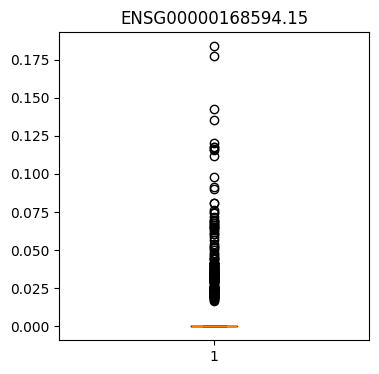


ENSG00000184459.8
Границы: [0.00, 0.00]
Количество выбросов: 172 
Минимальное значение выброса: 0.04233214233178667
Максимальное значение выброса: 0.6475911282289833


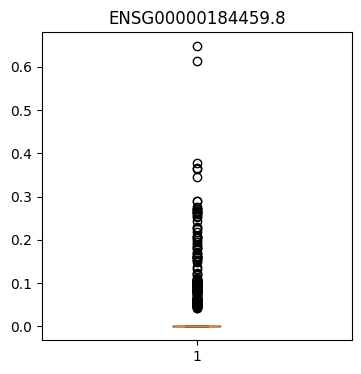


ENSG00000171060.11
Границы: [0.00, 0.00]
Количество выбросов: 173 
Минимальное значение выброса: 0.0164186926930161
Максимальное значение выброса: 0.13802283848601105


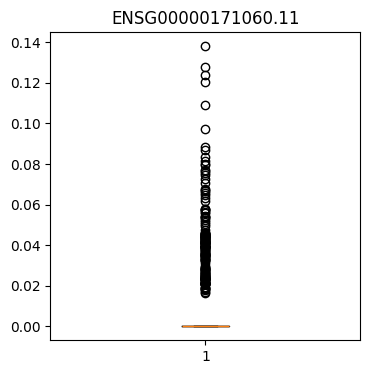


ENSG00000126266.3
Границы: [0.00, 0.00]
Количество выбросов: 173 
Минимальное значение выброса: 0.038642154615330035
Максимальное значение выброса: 0.3303471598941255


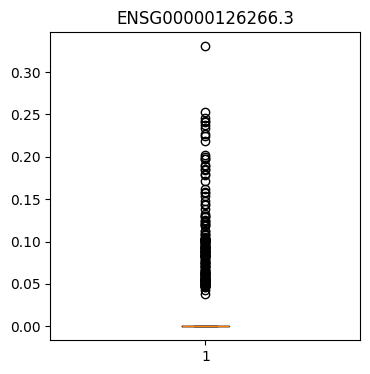


ENSG00000144644.14
Границы: [0.00, 0.00]
Количество выбросов: 171 
Минимальное значение выброса: 0.010633759076687477
Максимальное значение выброса: 2.002062771994182


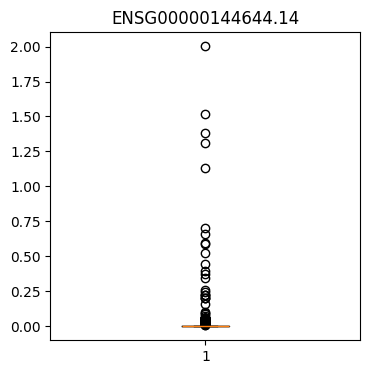


ENSG00000124091.9
Границы: [0.00, 0.00]
Количество выбросов: 171 
Минимальное значение выброса: 0.043197900210699816
Максимальное значение выброса: 1.1768048764224754


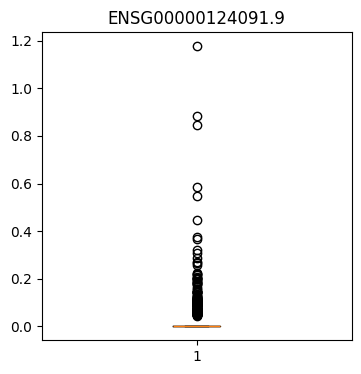


ENSG00000185774.16
Границы: [0.00, 0.00]
Количество выбросов: 171 
Минимальное значение выброса: 0.022991958663731837
Максимальное значение выброса: 2.5216035364302916


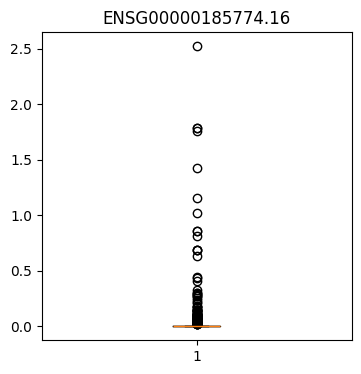


ENSG00000166800.10
Границы: [0.00, 0.00]
Количество выбросов: 173 
Минимальное значение выброса: 0.036531380505630956
Максимальное значение выброса: 0.755370911562866


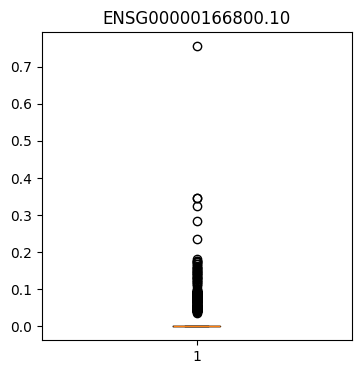


ENSG00000139151.16
Границы: [0.00, 0.00]
Количество выбросов: 173 
Минимальное значение выброса: 0.026141418532209915
Максимальное значение выброса: 0.26573692392745835


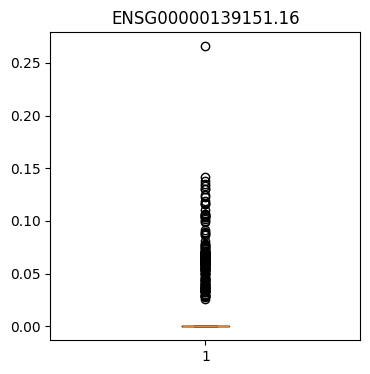


ENSG00000121446.20
Границы: [0.00, 0.00]
Количество выбросов: 171 
Минимальное значение выброса: 0.009952213559120253
Максимальное значение выброса: 0.09976940262087024


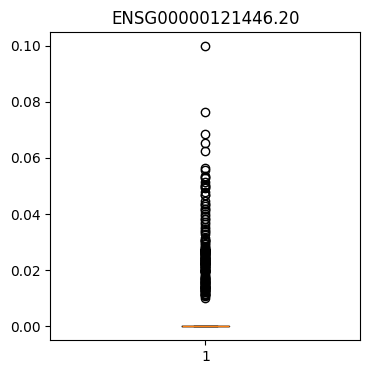


ENSG00000134595.8
Границы: [0.00, 0.00]
Количество выбросов: 171 
Минимальное значение выброса: 0.0362359494069832
Максимальное значение выброса: 1.2529501460305923


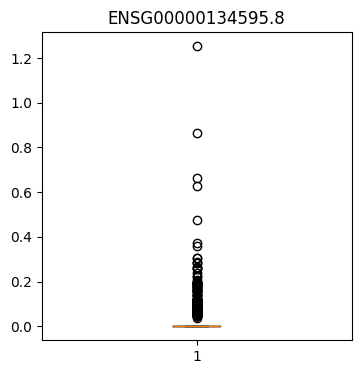


ENSG00000187144.11
Границы: [0.00, 0.00]
Количество выбросов: 173 
Минимальное значение выброса: 0.02108646377297697
Максимальное значение выброса: 0.17077932920836617


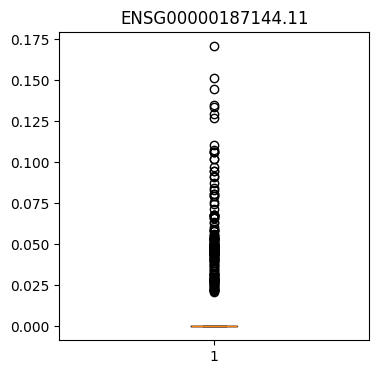


ENSG00000182111.9
Границы: [0.00, 0.00]
Количество выбросов: 173 
Минимальное значение выброса: 0.01859512104834631
Максимальное значение выброса: 0.17511242980562716


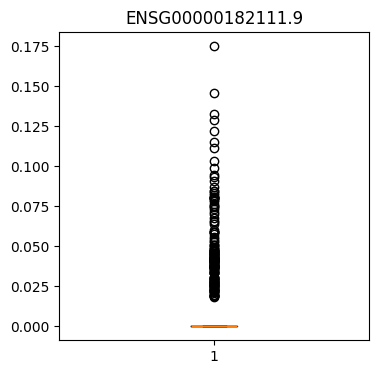

In [29]:
# Анализ выбросов
import matplotlib.pyplot as plt
cols = genes_log.columns.tolist()

def analysis_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    mini = Q1 - 1.5 * IQR
    maxi = Q3 + 1.5 * IQR
    outliers = data[(data[column] < mini) | (data[column] > maxi)]
    return outliers, mini, maxi

for col in cols:
    outliers, min, max = analysis_outliers(genes_log, col)
    if len(outliers) > 170:
      print(f"\n{col}")
      print(f"Границы: [{min:.2f}, {max:.2f}]")
      print(f"Количество выбросов: {len(outliers)} ")
      print(f"Минимальное значение выброса: {outliers[col].min()}")
      print(f"Максимальное значение выброса: {outliers[col].max()}")
      # print(f"Bыбросы: {outliers[col].tolist()}")
      plt.figure(figsize=(4, 4))
      plt.boxplot(genes_log[col])
      plt.title(col)
      plt.show()

In [30]:
# z-нормализация

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
!pip install mrmr_selection

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.2 MB/s eta 0:00:00


In [33]:
# Формирование subset2
from mrmr import mrmr_classif
subset2 = mrmr_classif(X=X_train,y=y_train,K=500)

100%|██████████| 500/500 [41:38<00:00,  5.00s/it]


In [34]:
# Формирование subset3
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

p_values = []
features = []

for col in X_train.columns:
    g0 = X_train.loc[y_train == 0, col]
    g1 = X_train.loc[y_train == 1, col]
    stat, p = mannwhitneyu(g0, g1)
    p_values.append(p)
    features.append(col)

_, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
subset3 = [col for col, pval in zip(features, pvals_corrected)if pval < 0.05]

In [35]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 1.2 MB/s eta 0:00:00


In [36]:
import warnings
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy import stats
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.metrics import make_scorer, f1_score, balanced_accuracy_score
from sklearn.model_selection import cross_val_predict
from sklearn.feature_selection import mutual_info_classif

X_train_scaled_df = pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)

warnings.filterwarnings('ignore')
scoring = {'f1_weighted': make_scorer(f1_score, average='weighted'),'balanced_accuracy': make_scorer(balanced_accuracy_score),'roc_auc': 'roc_auc'}

models = {
    'Logistic Regression': (LogisticRegression(),
                            {'C': (0.001, 10, 'log-uniform') }),
    'kNN': (KNeighborsClassifier(),
         {'n_neighbors': (2, 20),
          'p': [1, 2]}),
    'SVM': (SVC(probability=True),
         {'C': (0.001, 10.0, 'log-uniform'),
          'kernel': ['linear', 'rbf']}),
    'DecisionTree': (DecisionTreeClassifier(),
                      {'max_depth': (2, 20),
                        'min_samples_split': (2, 20),
                        'min_samples_leaf': (1, 10),
                        'max_features': ['sqrt', 'log2', None]}),
    'RandomForest': (RandomForestClassifier(),
                      {'n_estimators': (10, 100),
                      'max_depth': (3, 12),
                      'min_samples_split': (5, 20),
                      'min_samples_leaf': (1, 10),
                      'max_features': ['sqrt', 'log2', None]}),
    'ExtraTrees': (ExtraTreesClassifier(),
                  {'n_estimators': (10, 100),
                  'max_depth': (3, 12),
                  'min_samples_split': (5, 20),
                  'min_samples_leaf': (1, 10),
                  'max_features': ['sqrt', 'log2', None]}),
    'Adaboost': (AdaBoostClassifier(),
                            {'n_estimators': Integer(10, 200),
                             'learning_rate': Real(0.01, 1, prior='log-uniform')}),
    'GradientBoosting': (GradientBoostingClassifier(),
                      {'learning_rate': Real(0.01, 1, prior='log-uniform'),
                      'n_estimators': Integer(10, 100),
                      'subsample': Real(0.5, 1),
                      'max_depth': Integer(2, 5),
                      'min_samples_split': Integer(2, 20),
                      'min_samples_leaf': Integer(1, 10),
                      'max_features': Categorical(['sqrt', 'log2', None])}),
    'MLP': (MLPClassifier(),
         {'hidden_layer_sizes': (30,),
          'activation': Categorical(['relu', 'tanh', 'logistic', 'identity']),
          'learning_rate_init': Real(0.01, 0.5, prior='log-uniform')}),

        }

results = []
best_models = {}
for subset_name, subset_cols in tqdm([('subset1', subset1), ('subset2', subset2), ('subset3', subset3)]):

    X_tr = X_train_scaled_df[subset_cols]

    for model_name, (model, params) in models.items():
      bayes_search = BayesSearchCV(model, params, n_iter=10, cv=5, scoring='f1_weighted', n_jobs=-1, random_state=42)
      bayes_search.fit(X_tr, y_train)
      best_model = bayes_search.best_estimator_
      best_models[(model_name, subset_name)] = best_model

      cv_res = cross_validate(best_model,X_tr,y_train,cv=5,scoring=scoring,n_jobs=-1)

      results.append({
          'Model': model_name,
          'Features': subset_name,
          'F1_weighted': cv_res['test_f1_weighted'].mean(),
          'Balanced Accuracy': cv_res['test_balanced_accuracy'].mean(),
          'ROC_AUC': cv_res['test_roc_auc'].mean(),
      })

100%|██████████| 3/3 [58:30<00:00, 1170.28s/it]


In [37]:
results_df = pd.DataFrame(results)
print(results_df.sort_values(by='F1_weighted', ascending=False))
print(best_model)

                  Model Features  F1_weighted  Balanced Accuracy   ROC_AUC
17                  MLP  subset2     0.839151           0.832842  0.905510
9   Logistic Regression  subset2     0.815397           0.786096  0.896568
11                  SVM  subset2     0.809672           0.777136  0.878950
26                  MLP  subset3     0.744987           0.731536  0.795153
18  Logistic Regression  subset3     0.733297           0.717973  0.766429
20                  SVM  subset3     0.709617           0.683666  0.748037
15             Adaboost  subset2     0.706198           0.672625  0.725084
24             Adaboost  subset3     0.686198           0.650962  0.704062
16     GradientBoosting  subset2     0.678878           0.639400  0.720164
13         RandomForest  subset2     0.655392           0.611696  0.707192
14           ExtraTrees  subset2     0.652116           0.611541  0.709670
6              Adaboost  subset1     0.652036           0.611145  0.670066
25     GradientBoosting  

Оптимальное число признаков: 396
Лучший F1_weighted: 0.8243542193891494
Лучшая модель: LogisticRegression(C=0.04369339947510315)


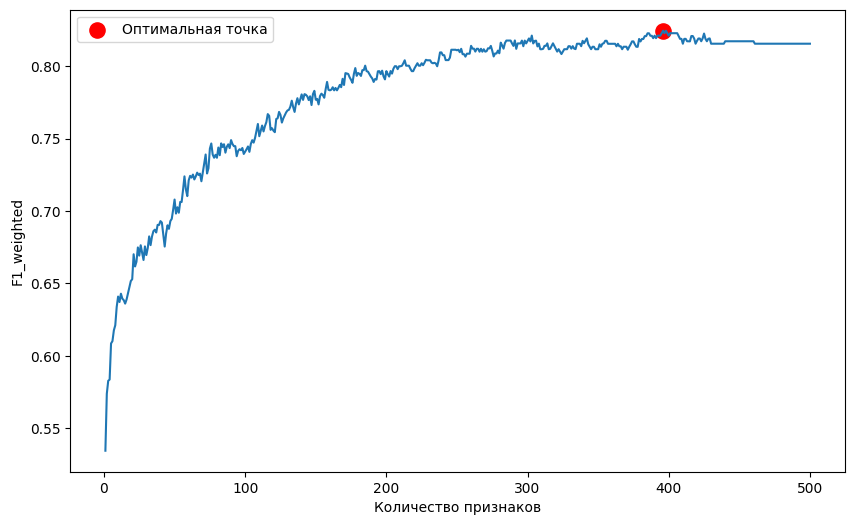

In [227]:
from sklearn.feature_selection import RFECV

X_tr = X_train_scaled_df[subset2]
y_tr = y_train
best_rf = best_models[('Logistic Regression', 'subset2')]
rfecv = RFECV(estimator=best_rf,step=1,min_features_to_select=1,cv=5,scoring='f1_weighted',n_jobs=-1)
rfecv.fit(X_tr, y_tr)
opt_features = rfecv.n_features_
print("Оптимальное число признаков:", opt_features)
best_f1 = np.max(rfecv.cv_results_['mean_test_score'])
print("Лучший F1_weighted:", best_f1)
print("Лучшая модель:", best_rf)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'])
plt.scatter(opt_features,best_f1,color='red',s=120,label='Оптимальная точка')
plt.xlabel("Количество признаков")
plt.ylabel("F1_weighted")
plt.legend()
plt.show()

F1_weighted: 0.6857450415271118
Balanced Accuracy: 0.6675579322638145
ROC_AUC: 0.7054367201426025


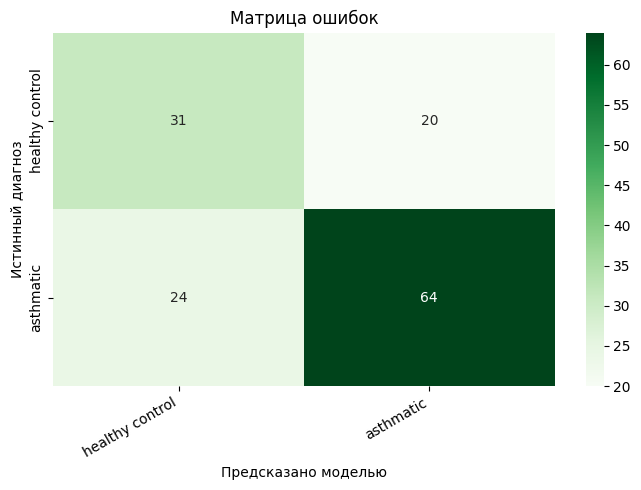

healthy control: Чувствительность = 0.608, Специфичность = 0.727
asthmatic: Чувствительность = 0.727, Специфичность = 0.608

 0.6636690647482014 0.6834532374100719


In [228]:
import seaborn as sns

#best_model = MLPClassifier(activation='relu', hidden_layer_sizes=(30,), early_stopping=True, n_iter_no_change=10, max_iter=500,
              #learning_rate_init=0.005, alpha=0.001)
selected_features = X_tr.columns[rfecv.support_]
best_model=LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, C=0.01, class_weight='balanced')
X_tr = X_train_scaled_df[selected_features]
X_te = X_test_scaled_df[selected_features]
best_model.fit(X_tr, y_train)
y_proba_test = best_model.predict_proba(X_te)[:, 1]
y_pred_test = (y_proba_test > threshold).astype(int)

# Вычислим метрики для лучшей модели
f1 = f1_score(y_test, y_pred_test, average='weighted')
bal_acc = balanced_accuracy_score(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, y_proba_test)
print(f"F1_weighted: {f1}")
print(f"Balanced Accuracy: {bal_acc}")
print(f"ROC_AUC: {roc_auc}")

# Матрица ошибок
labels = ['healthy control', 'asthmatic']
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.title('Матрица ошибок')
plt.xlabel('Предсказано моделью')
plt.ylabel('Истинный диагноз')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Вычислим специфичность и чувствительность для каждого класса
n_classes = len(labels)
sensitivity = []
specificity = []
for i in range(n_classes):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)
    TPR = TP / (TP + FN) # чувствительность (Recall)
    TNR = TN / (TN + FP) # специфичность
    sensitivity.append(TPR)
    specificity.append(TNR)
for i in range(n_classes):
    print(f"{labels[i]}: Чувствительность = {sensitivity[i]:.3f}, Специфичность = {specificity[i]:.3f}")

train_score = best_model.score(X_tr, y_train)
test_score = best_model.score(X_te, y_test)

print('\n',train_score, test_score)

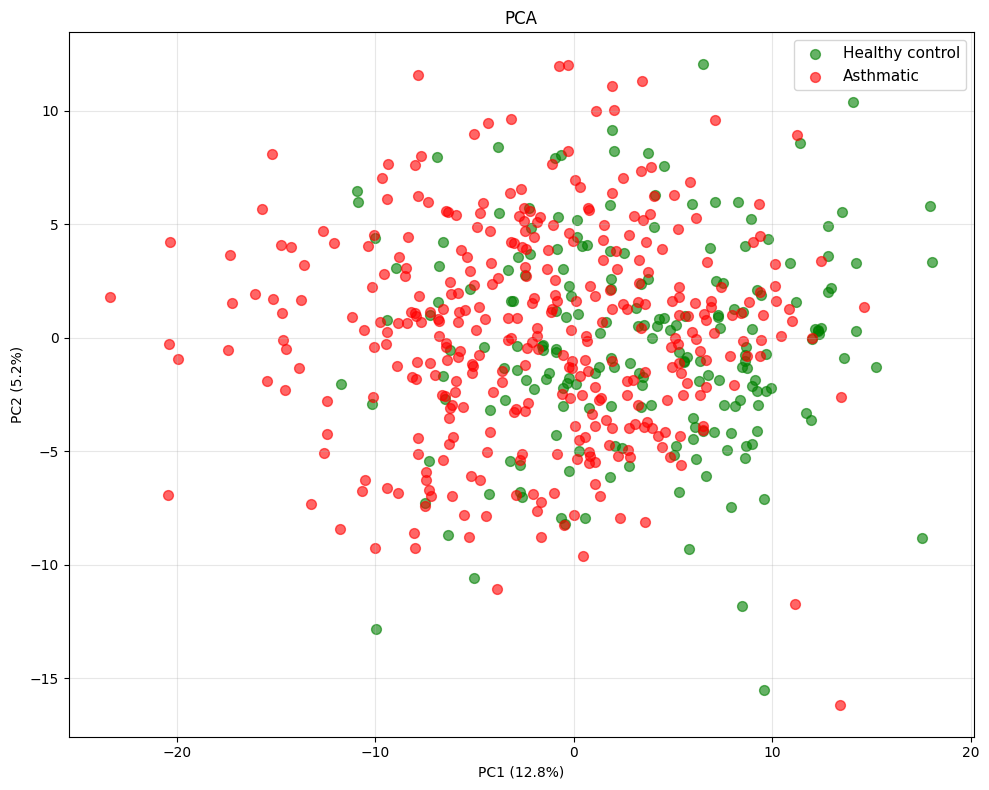

In [229]:
from sklearn.decomposition import PCA

X_pca = X_train_scaled_df[selected_features].copy()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_pca)
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Class': y_train.values
})
pca_df['Class'] = pca_df['Class'].map({0: 'Healthy control', 1: 'Asthmatic'})

plt.figure(figsize=(10, 8))
healthy = pca_df[pca_df['Class'] == 'Healthy control']
asthmatic = pca_df[pca_df['Class'] == 'Asthmatic']
plt.scatter(healthy['PC1'], healthy['PC2'], c='green', label='Healthy control', alpha=0.6, s=50)
plt.scatter(asthmatic['PC1'], asthmatic['PC2'],  c='red', label='Asthmatic', alpha=0.6, s=50)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('PCA')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [230]:
from sklearn.feature_selection import f_classif
from statsmodels.stats.multitest import fdrcorrection
from scipy.stats import ranksums

def calculate_mann_whitney(X, y, gene):
    group0 = X[y == 0][gene].values
    group1 = X[y == 1][gene].values
    stat, p_val = ranksums(group0, group1)
    return abs(stat), p_val

results = []
for gene in subset2:
    stat, p_val = calculate_mann_whitney(X_train_scaled_df, y_train, gene)
    results.append({'gene': gene, 'statistic': stat, 'p_value': p_val})

mw_results = pd.DataFrame(results)
mapping = protein_genes[['gene_id', 'gene_name']]
mw_results=mw_results.merge(mapping, left_on='gene', right_on='gene_id', how='left')
mw_results = mw_results.drop('gene_id', axis=1)
reject, padj = fdrcorrection(mw_results['p_value'])
mw_results = mw_results.sort_values('p_value', ascending=True)

In [231]:
print(mw_results.head(10))

                   gene  statistic       p_value gene_name
0    ENSG00000136273.13   5.515195  3.483934e-08      HUS1
20   ENSG00000172171.11   5.196078  2.035374e-07      TEFM
142  ENSG00000122565.19   5.029939  4.906359e-07      CBX3
37   ENSG00000116863.11   5.003620  5.626360e-07   ADPRHL2
19    ENSG00000162630.6   4.942209  7.724230e-07   B3GALT2
64   ENSG00000158773.14   4.929050  8.263059e-07      USF1
27    ENSG00000140830.9   4.911504  9.038061e-07    TXNL4B
62    ENSG00000205269.6   4.889023  1.013377e-06  TMEM170B
15   ENSG00000240849.11   4.889023  1.013377e-06   TMEM189
180  ENSG00000150782.12   4.853383  1.213732e-06      IL18
